In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Load data

In [2]:
df =  pd.read_csv("../../data/cleaned_heart_disease.csv")
df.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,max_hr,exercise_angina,old_peak,st_slope,heartdisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              918 non-null    int64  
 1   sex              918 non-null    object 
 2   chestpaintype    918 non-null    object 
 3   restingbp        918 non-null    int64  
 4   cholesterol      918 non-null    int64  
 5   fastingbs        918 non-null    int64  
 6   restingecg       918 non-null    object 
 7   max_hr           918 non-null    int64  
 8   exercise_angina  918 non-null    object 
 9   old_peak         918 non-null    float64
 10  st_slope         918 non-null    object 
 11  heartdisease     918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## distribution of target(heart disease)

Text(0.5, 0, 'Heart Disease')

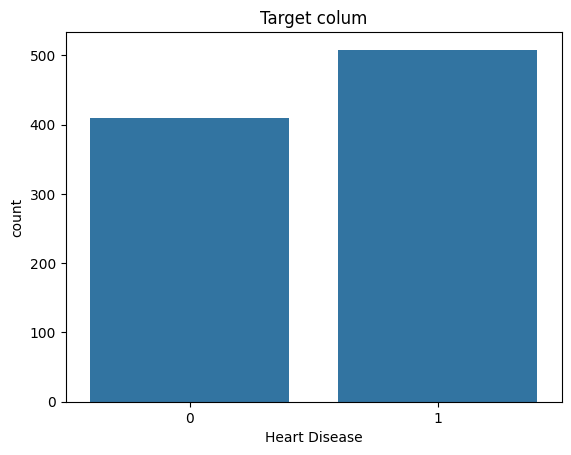

In [6]:
sns.barplot(df['heartdisease'].value_counts())
plt.title('Target colum')
plt.xlabel('Heart Disease')

### check proportion of those with heart disease and those without

In [11]:
df['heartdisease'].value_counts(normalize=True)

heartdisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [19]:
numeric_cols =  df.select_dtypes('number').columns.drop(["fastingbs", "heartdisease"]).to_list()
numeric_cols

['age', 'restingbp', 'cholesterol', 'max_hr', 'old_peak']

In [25]:
categorical_col =  df.select_dtypes('object').columns.to_list() + ["fastingbs"]
categorical_col

['sex',
 'chestpaintype',
 'restingecg',
 'exercise_angina',
 'st_slope',
 'fastingbs']

## Numeric columns

In [26]:
df[numeric_cols].describe()

,age,restingbp,cholesterol,max_hr,old_peak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


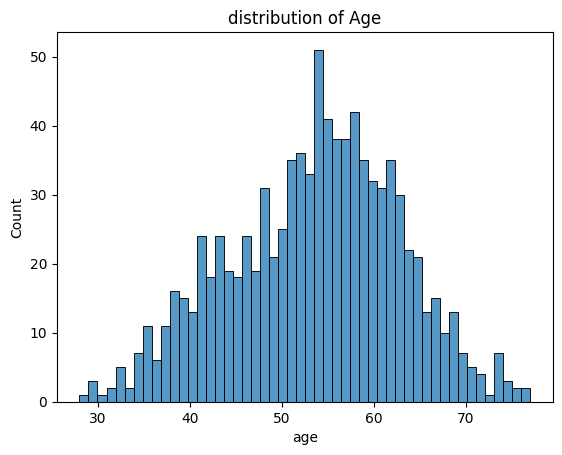

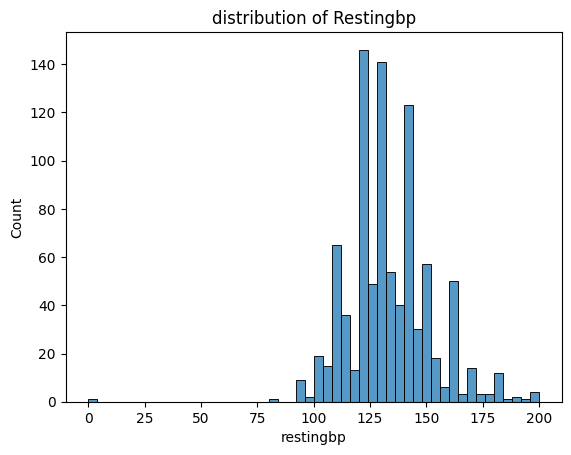

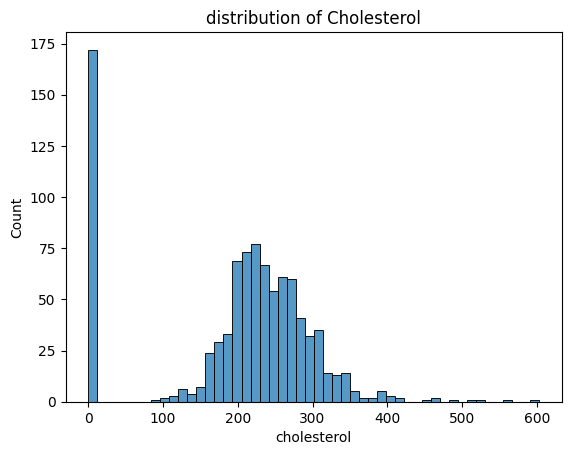

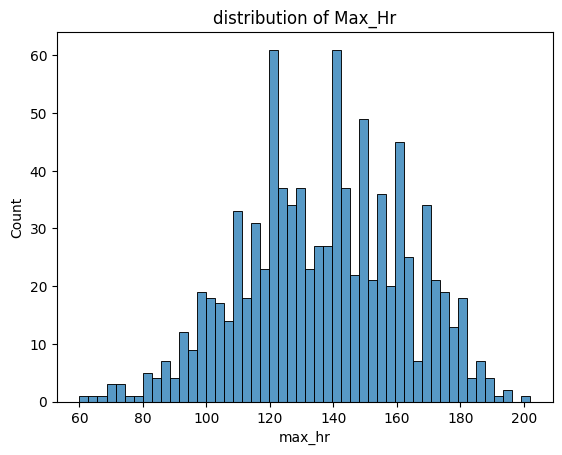

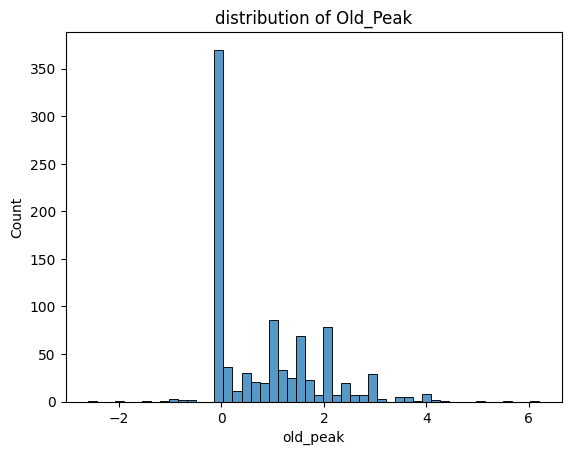

In [27]:
for cols in numeric_cols:
    sns.histplot(df[cols], bins=50)
    plt.title(f'distribution of {cols.title()}')
    plt.show()

## Categorical Columns

Sex
sex
M    725
F    193
Name: count, dtype: int64


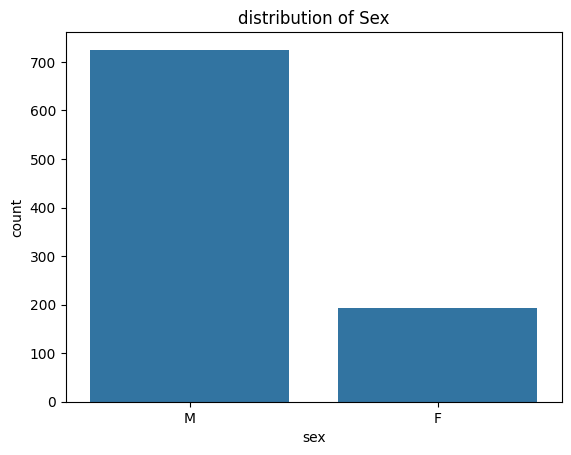

Chestpaintype
chestpaintype
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


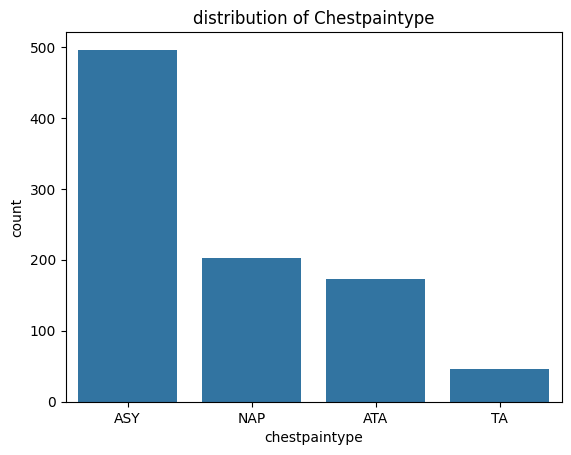

Restingecg
restingecg
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


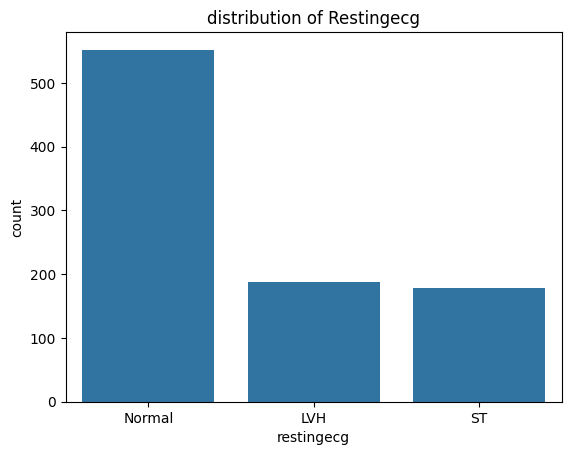

Exercise_Angina
exercise_angina
N    547
Y    371
Name: count, dtype: int64


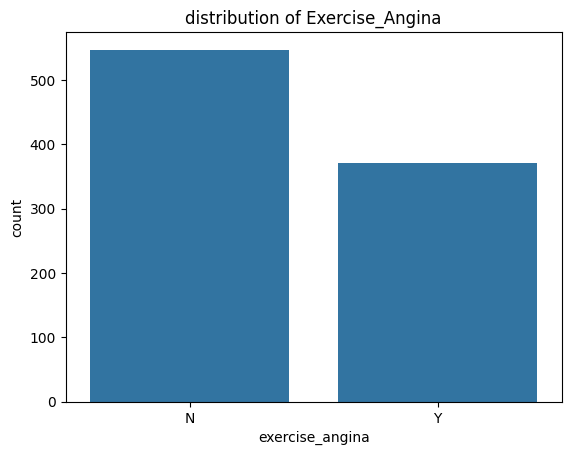

St_Slope
st_slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


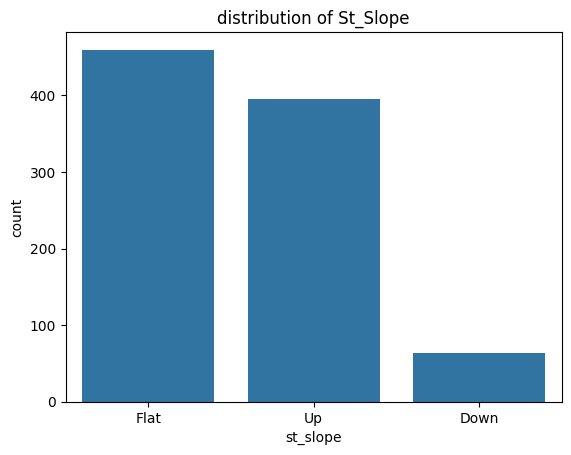

Fastingbs
fastingbs
0    704
1    214
Name: count, dtype: int64


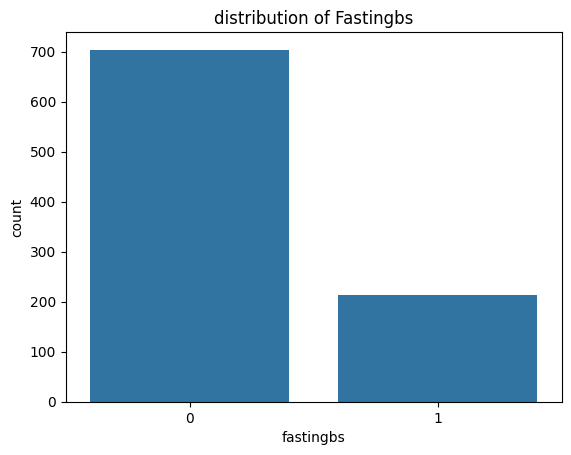

In [28]:
for cols in categorical_col:
    cat_count = df[cols].value_counts()
    print(f'{cols.title()}')
    print('=====================')
    print(cat_count)
    sns.barplot(cat_count)
    plt.title(f'distribution of {cols.title()}')
    plt.show()

## Correlation Analysis 

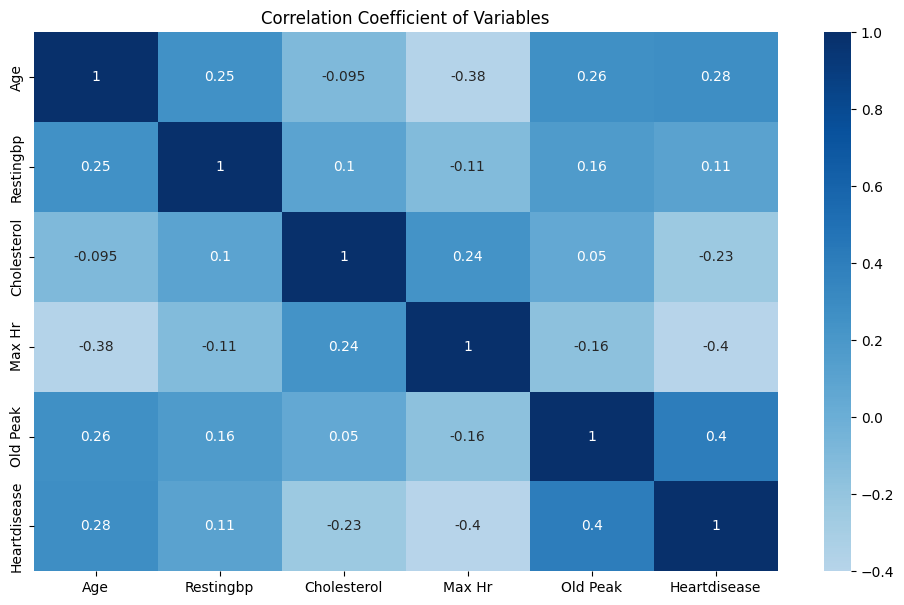

In [57]:
corr = df[numeric_cols + ['heartdisease']].corr()

plt.figure(figsize=(12,7))
plt.title("Correlation Coefficient of Variables")
ax = sns.heatmap(corr , annot=True, cmap="Blues", center=0.0)
ax.set_xticklabels(corr.columns.str.replace("_", " ").str.title())
ax.set_yticklabels(corr.columns.str.replace("_", " ").str.title());

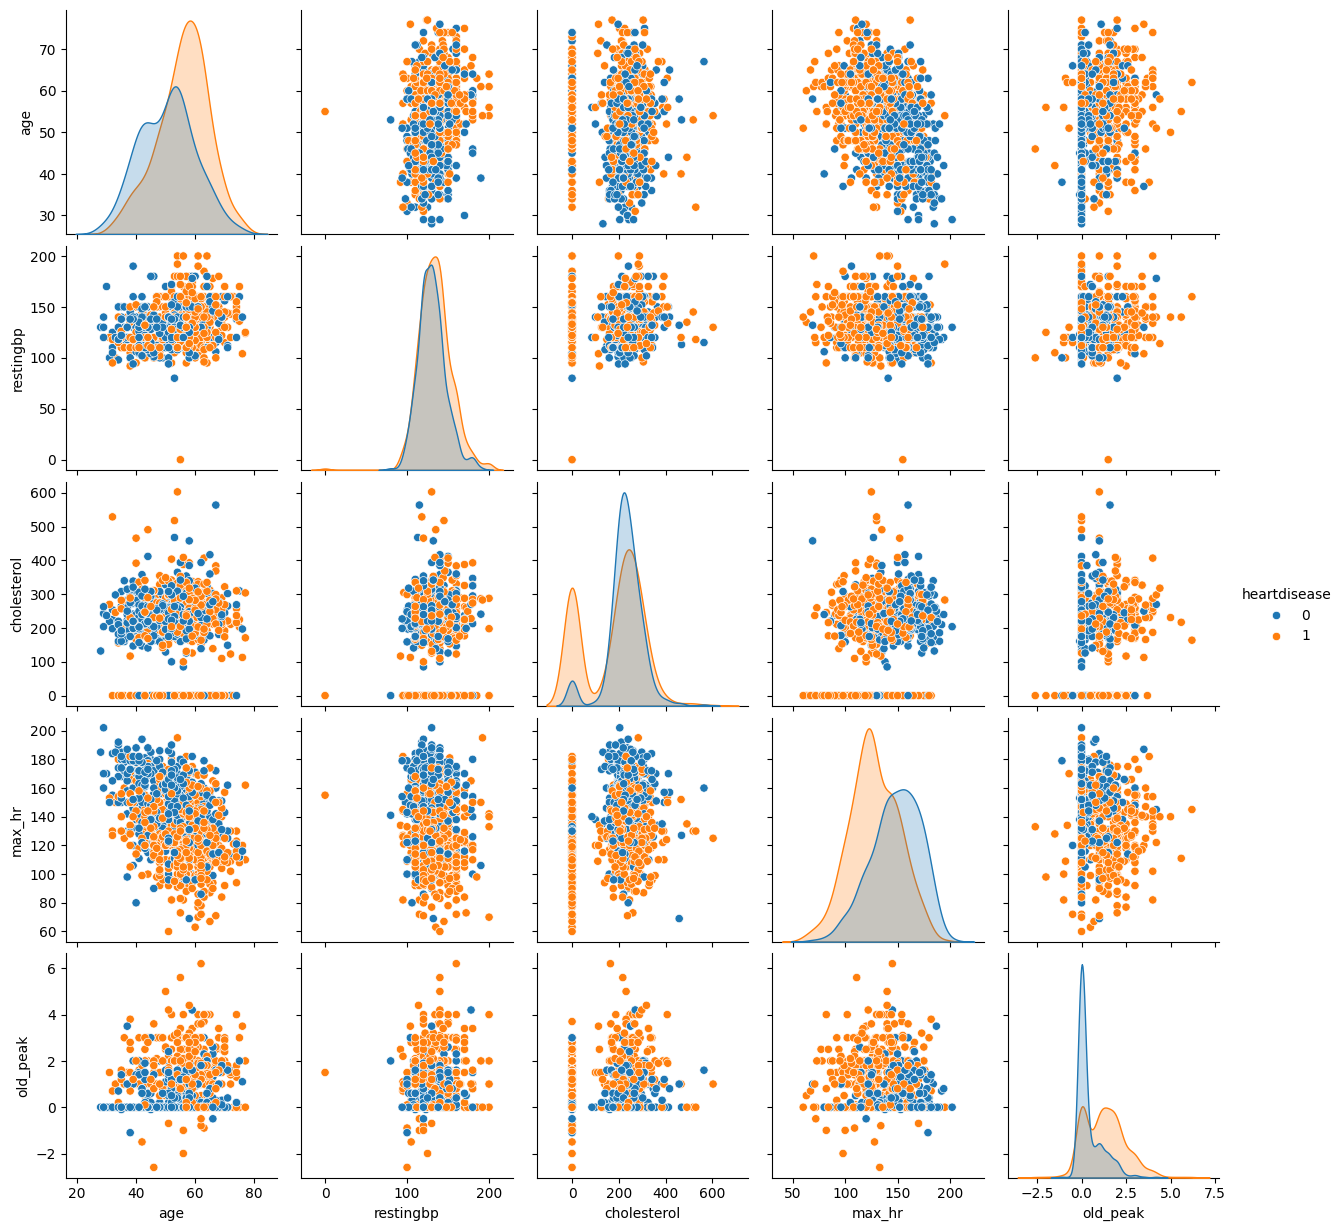

In [47]:
sns.pairplot(df[numeric_cols + ["heartdisease"]], hue='heartdisease')

## Average Values By Heart disease

heartdisease
0    50.551220
1    55.899606
Name: age, dtype: float64


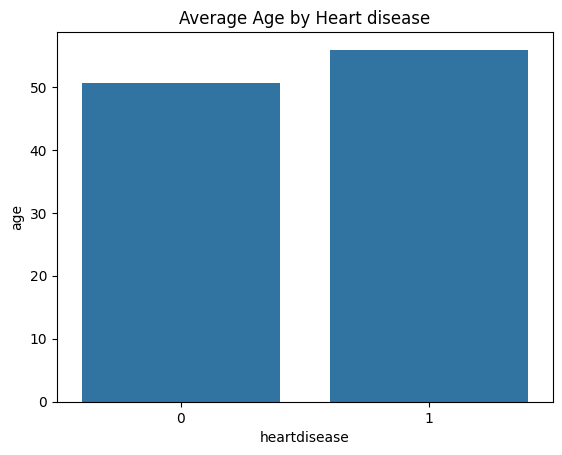

heartdisease
0    130.180488
1    134.185039
Name: restingbp, dtype: float64


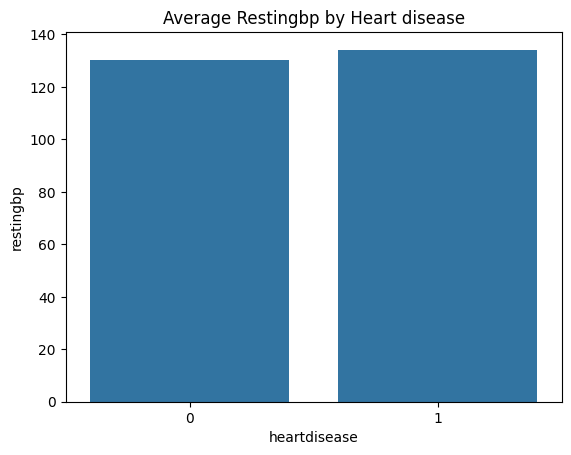

heartdisease
0    227.121951
1    175.940945
Name: cholesterol, dtype: float64


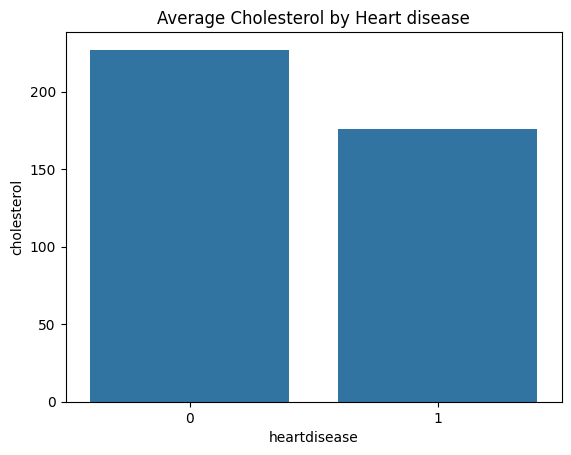

heartdisease
0    148.151220
1    127.655512
Name: max_hr, dtype: float64


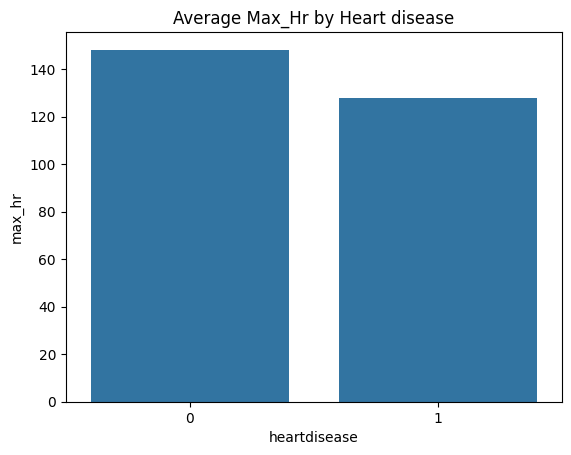

heartdisease
0    0.408049
1    1.274213
Name: old_peak, dtype: float64


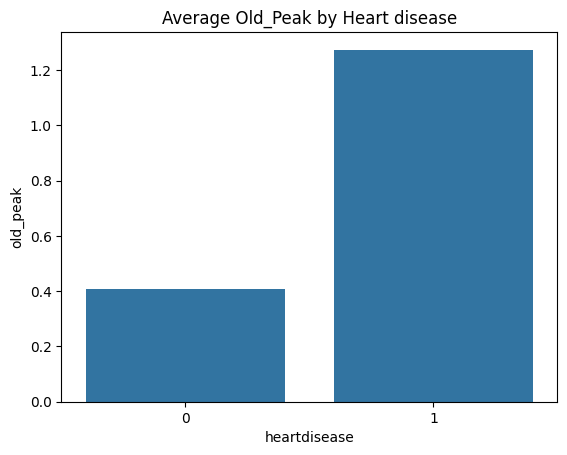

In [48]:
for cols in numeric_cols:
    group_average =  df.groupby('heartdisease')[cols].mean()
    print(group_average)
    sns.barplot(group_average)
    plt.title(f'Average {cols.title() } by Heart disease')
    plt.show()

sex
F    0.259067
M    0.631724
Name: heartdisease, dtype: float64


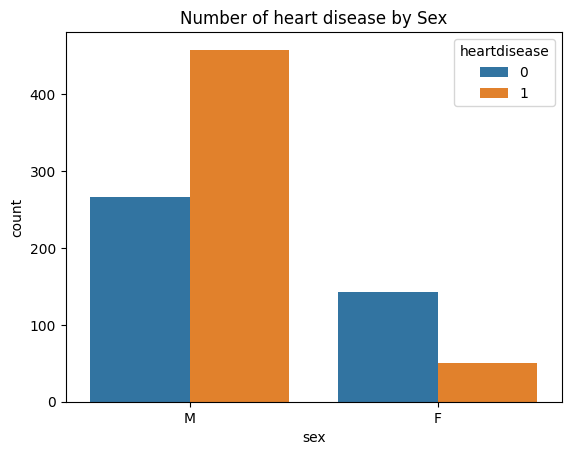

chestpaintype
ASY    0.790323
ATA    0.138728
NAP    0.354680
TA     0.434783
Name: heartdisease, dtype: float64


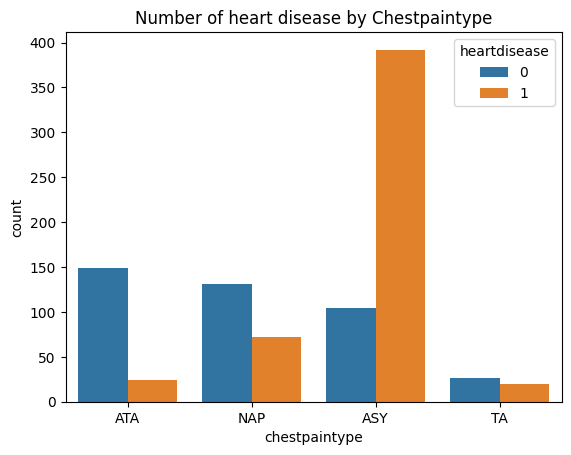

restingecg
LVH       0.563830
Normal    0.516304
ST        0.657303
Name: heartdisease, dtype: float64


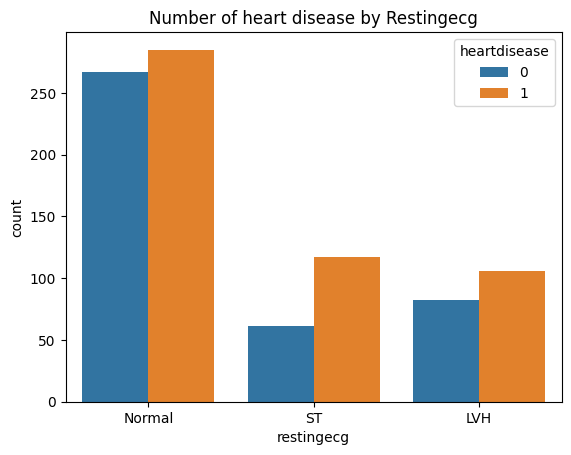

exercise_angina
N    0.351005
Y    0.851752
Name: heartdisease, dtype: float64


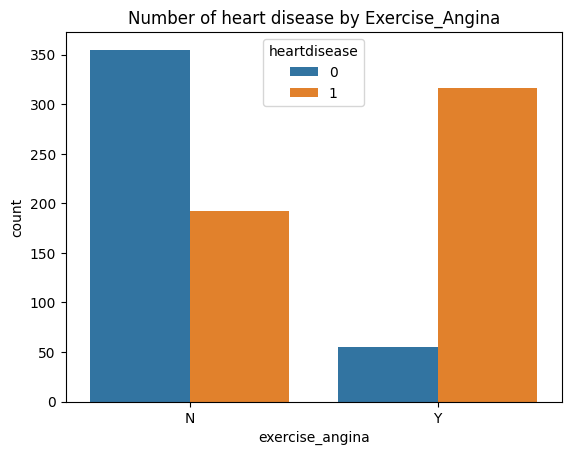

st_slope
Down    0.777778
Flat    0.828261
Up      0.197468
Name: heartdisease, dtype: float64


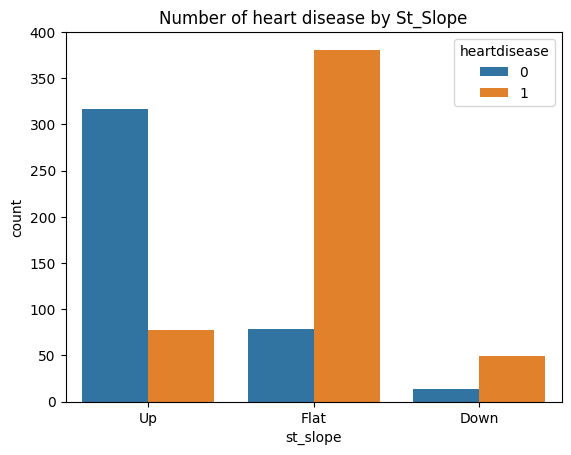

fastingbs
0    0.480114
1    0.794393
Name: heartdisease, dtype: float64


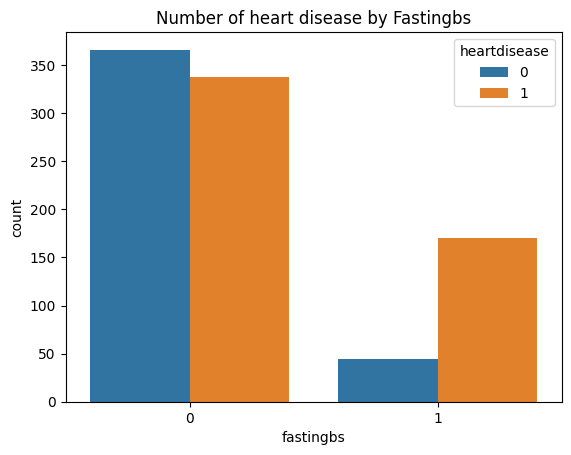

In [49]:
for col in categorical_col:
    group_disease_rate = df.groupby(col)["heartdisease"].mean()
    print(group_disease_rate)
    sns.countplot(x=df[col].astype(str), hue=df["heartdisease"])
    plt.title(f"Number of heart disease by {col.title()}")
    plt.show()

## Mutual Information Score 

In [51]:
from sklearn.metrics import mutual_info_score

In [53]:
df[categorical_col].apply(
    lambda features: mutual_info_score(df['heartdisease'], features)
).sort_values(ascending = False)

st_slope           0.207474
chestpaintype      0.155988
exercise_angina    0.131680
sex                0.047477
fastingbs          0.038040
restingecg         0.006045
dtype: float64